In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import matplotlib.pyplot as plt

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.87MB/s]


Train size: 60000
Test size: 10000


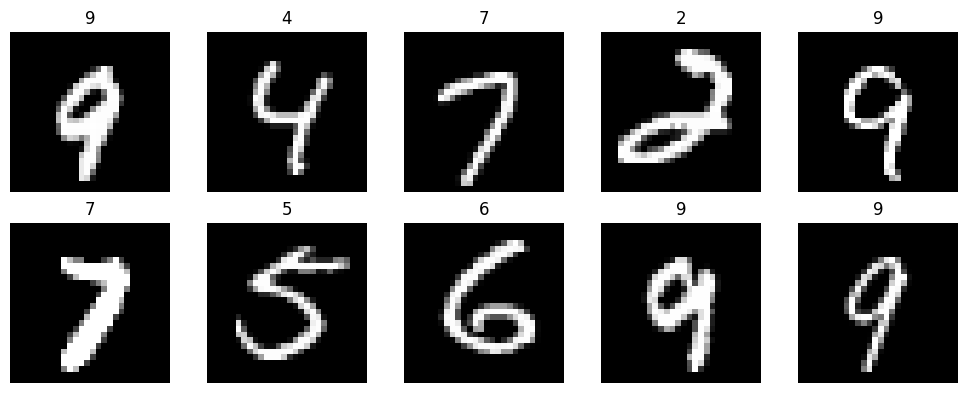

Using device: cpu


In [ ]:

# 1) Simple CNN
# 2) Deep CNN + Dropout
# Dataset: MNIST

# ===== Random Seed =====

torch.manual_seed(42)
random.seed(42)

# ===== Hyperparameters =====

batch_size = 32
learning_rate = 0.001
epochs = 5

# TRANSFORM
# MNIST images are already 28x28
# No need for Resize

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

# DATASET

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)


# DATALOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

# SHOW SAMPLE IMAGES

plt.figure(figsize=(10,4))

for i in range(10):
    img, label = random.choice(train_dataset)
    img = img.squeeze() * 0.5 + 0.5
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')
plt.tight_layout()
plt.show()

# DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available()
     else "cpu"
)

print("Using device:", device)


In [ ]:

# MODEL 1: SIMPLE CNN
# Conv -> ReLU -> BatchNorm -> Pool

simple_cnn = nn.Sequential(
    nn.Conv2d(1,32,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2),

    nn.Conv2d(32,64,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7,128),
    nn.ReLU(),


    nn.Linear(128,10)

).to(device)

# MODEL 2: DEEP CNN + DROPOUT
# More layers + regularization

deep_cnn = nn.Sequential(
    nn.Conv2d(1,32,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),

    nn.Conv2d(32,64,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),
    nn.MaxPool2d(2),

    nn.Conv2d(64,128,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),
    nn.MaxPool2d(2),
    nn.Flatten(),

    nn.Linear(128 * 7 * 7,256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256,10)

).to(device)



In [ ]:
# ===== Training + Evaluation Function =====

def train_and_evaluate(model, model_name, train_loader, test_loader, epochs=5):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_acc_history = []
    test_acc_history = []

    train_loss_history = []
    test_loss_history = []

    print(f"\n===== Training {model_name} =====")

    # ===== Training =====

    for epoch in range(epochs):

        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss = total_loss / len(train_loader)

        train_acc_history.append(train_acc)
        train_loss_history.append(train_loss)

        # ===== Testing =====

        model.eval()
        correct = 0
        total = 0
        total_test_loss = 0

        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)

                loss = criterion(outputs, labels)
                total_test_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_acc = 100 * correct / total
        avg_test_loss = total_test_loss / len(test_loader)

        test_acc_history.append(test_acc)
        test_loss_history.append(avg_test_loss)

        print(f"{model_name} Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Test Loss: {avg_test_loss:.4f}")
        print(f"Test Accuracy: {test_acc:.2f}%")
        print("=" * 50)

    return (
        test_acc,
        avg_test_loss,
        train_acc_history,
        test_acc_history,
        train_loss_history,
        test_loss_history
    )

In [11]:

# RUN MODELS

acc_simple = train_and_evaluate(simple_cnn,"Simple CNN",train_loader,test_loader,epochs=epochs)
acc_deep = train_and_evaluate(deep_cnn,"Deep CNN",train_loader,test_loader,epochs=epochs)




===== Training Simple CNN =====
Simple CNN Epoch 1
Train Loss: 0.0343
Train Accuracy: 99.04%
Test Loss: 0.0364
Test Accuracy: 99.00%
Simple CNN Epoch 2
Train Loss: 0.0216
Train Accuracy: 99.34%
Test Loss: 0.0350
Test Accuracy: 99.12%
Simple CNN Epoch 3
Train Loss: 0.0161
Train Accuracy: 99.51%
Test Loss: 0.0452
Test Accuracy: 98.91%
Simple CNN Epoch 4
Train Loss: 0.0164
Train Accuracy: 99.49%
Test Loss: 0.0523
Test Accuracy: 98.88%
Simple CNN Epoch 5
Train Loss: 0.0135
Train Accuracy: 99.58%
Test Loss: 0.0532
Test Accuracy: 98.80%

===== Training Deep CNN =====
Deep CNN Epoch 1
Train Loss: 0.1745
Train Accuracy: 94.92%
Test Loss: 0.0397
Test Accuracy: 98.70%
Deep CNN Epoch 2
Train Loss: 0.0888
Train Accuracy: 97.56%
Test Loss: 0.0499
Test Accuracy: 98.73%
Deep CNN Epoch 3
Train Loss: 0.0718
Train Accuracy: 98.12%
Test Loss: 0.0505
Test Accuracy: 98.84%
Deep CNN Epoch 4
Train Loss: 0.0576
Train Accuracy: 98.48%
Test Loss: 0.0378
Test Accuracy: 99.04%
Deep CNN Epoch 5
Train Loss: 0.0492

In [12]:

# FINAL COMPARISON

print("\n===== FINAL COMPARISON =====")
print(f"Simple CNN Accuracy : {acc_simple[0]:.2f}%")
print(f"Simple CNN Loss     : {acc_simple[1]:.4f}")
print(f"Deep CNN Accuracy   : {acc_deep[0]:.2f}%")
print(f"Deep CNN Loss       : {acc_deep[1]:.4f}")



===== FINAL COMPARISON =====
Simple CNN Accuracy : 98.80%
Simple CNN Loss     : 0.0532
Deep CNN Accuracy   : 99.19%
Deep CNN Loss       : 0.0399


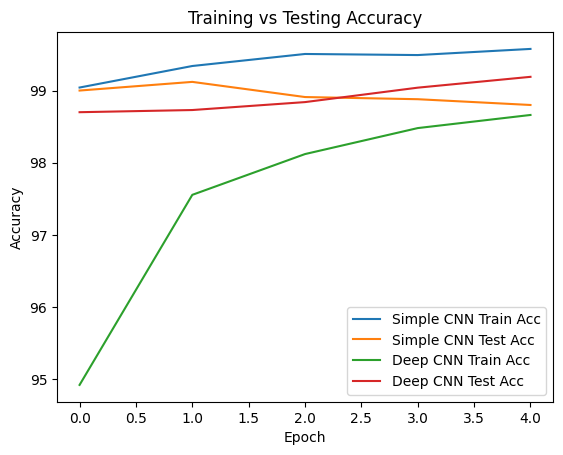

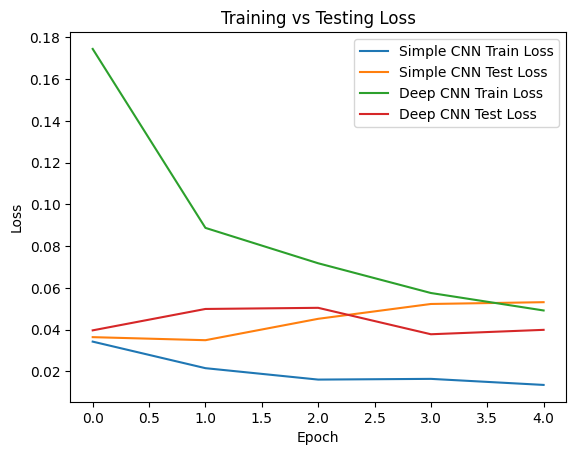

In [13]:
# VISUALIZATION

# ===== Accuracy =====

plt.plot(acc_simple[2],label='Simple CNN Train Acc')
plt.plot(acc_simple[3],label='Simple CNN Test Acc')
plt.plot(acc_deep[2],label='Deep CNN Train Acc')
plt.plot(acc_deep[3],label='Deep CNN Test Acc')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")

plt.legend()
plt.show()

# ===== Loss =====

plt.plot(acc_simple[4],label='Simple CNN Train Loss')
plt.plot(acc_simple[5],label='Simple CNN Test Loss')
plt.plot(acc_deep[4],label='Deep CNN Train Loss')
plt.plot(acc_deep[5],label='Deep CNN Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")

plt.legend()

plt.show()